✓ Dataset loaded successfully
Shape: (49287, 9)

BASIC EXPLORATION
1. Total matches: 49,287
2. Year range: 1872 - 2026
3. Unique countries: 333
4. Most frequent home team:
home_team
Brazil    614
Name: count, dtype: int64

GOALS ANALYSIS
5. Average goals per match: 2.94
6. Highest scoring match (31.0 goals):
      date home_team      away_team  home_score  away_score
2001-04-11 Australia American Samoa        31.0         0.0

7. Total home goals: 86,426.0
   Total away goals: 58,192.0
   → More goals scored at HOME

8. Most common total goals: 2.0 (appears 10927 times)

MATCH RESULTS
9. Home win percentage: 48.91%
   Draw percentage: 22.86%
   Away win percentage: 28.23%

10. Home advantage analysis:
    ✓ YES, home advantage clearly exists

11. Country with most wins historically:
    Brazil - 670 wins

GENERATING VISUALIZATIONS


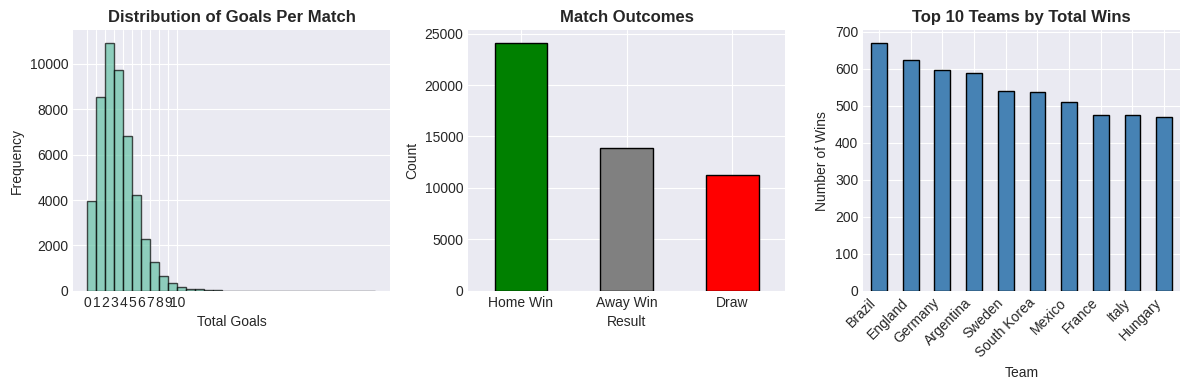

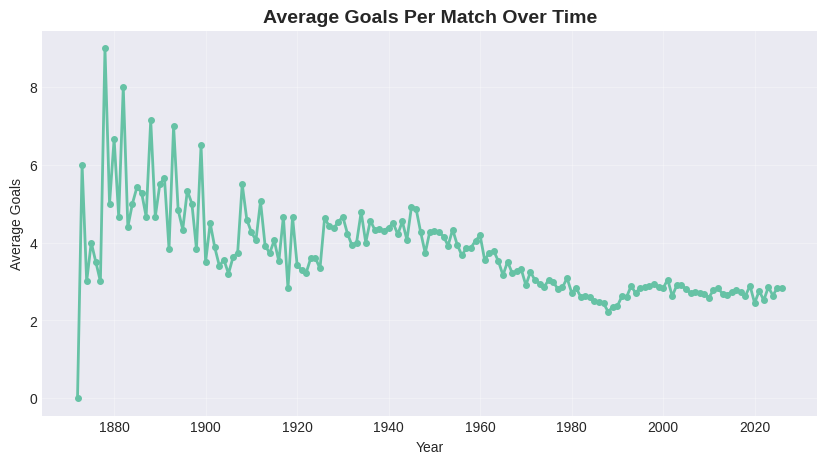


✓ All visualizations displayed
FOOTBALL ANALYSIS COMPLETE


In [2]:
# Dataset: International Football Results (1872-2024)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==================== STEP 1: LOAD DATA ====================
df = pd.read_csv("results.csv")
print("✓ Dataset loaded successfully")
print(f"Shape: {df.shape}\n")

# Convert date column
df["date"] = pd.to_datetime(df["date"])

# ==================== BASIC EXPLORATION ====================
print("=" * 50)
print("BASIC EXPLORATION")
print("=" * 50)

# 1. How many matches?
num_matches = df.shape[0]
print(f"1. Total matches: {num_matches:,}")

# 2. Earliest and latest year
earliest = df["date"].min().year
latest = df["date"].max().year
print(f"2. Year range: {earliest} - {latest}")

# 3. Unique countries
home_countries = set(df["home_team"].unique())
away_countries = set(df["away_team"].unique())
all_countries = home_countries.union(away_countries)
print(f"3. Unique countries: {len(all_countries)}")

# 4. Most frequent home team
most_common_home = df["home_team"].value_counts().head(1)
print(f"4. Most frequent home team:\n{most_common_home}\n")

# ==================== GOALS ANALYSIS ====================
print("=" * 50)
print("GOALS ANALYSIS")
print("=" * 50)

# Create total goals column
df["total_goals"] = df["home_score"] + df["away_score"]

# 5. Average goals per match
avg_goals = df["total_goals"].mean()
print(f"5. Average goals per match: {avg_goals:.2f}")

# 6. Highest scoring match
max_goals = df["total_goals"].max()
highest_scoring = df[df["total_goals"] == max_goals]
print(f"6. Highest scoring match ({max_goals} goals):")
print(highest_scoring[["date", "home_team", "away_team", "home_score", "away_score"]].to_string(index=False))

# 7. Home vs Away goals
total_home = df["home_score"].sum()
total_away = df["away_score"].sum()
print(f"\n7. Total home goals: {total_home:,}")
print(f"   Total away goals: {total_away:,}")
if total_home > total_away:
    print("   → More goals scored at HOME")
else:
    print("   → More goals scored at AWAY")

# 8. Most common total goals
common_goals = df["total_goals"].value_counts().head(1)
common_value = common_goals.index[0]
common_count = common_goals.values[0]
print(f"\n8. Most common total goals: {common_value} (appears {common_count} times)\n")

# ==================== MATCH RESULTS ====================
print("=" * 50)
print("MATCH RESULTS")
print("=" * 50)

# Create match outcome function
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return "Home Win"
    elif row["home_score"] < row["away_score"]:
        return "Away Win"
    else:
        return "Draw"

df["result"] = df.apply(match_result, axis=1)

# 9. Percentage of home wins
result_counts = df["result"].value_counts()
home_win_pct = (result_counts["Home Win"] / num_matches) * 100
print(f"9. Home win percentage: {home_win_pct:.2f}%")
print(f"   Draw percentage: {(result_counts['Draw'] / num_matches) * 100:.2f}%")
print(f"   Away win percentage: {(result_counts['Away Win'] / num_matches) * 100:.2f}%")

# 10. Does home advantage exist?
print("\n10. Home advantage analysis:")
if home_win_pct > (result_counts["Away Win"] / num_matches) * 100:
    print("    ✓ YES, home advantage clearly exists")
else:
    print("    ✗ No clear home advantage")

# 11. Country with most wins
home_wins = df[df["result"] == "Home Win"]["home_team"].value_counts()
away_wins = df[df["result"] == "Away Win"]["away_team"].value_counts()
total_wins = home_wins.add(away_wins, fill_value=0)
top_team = total_wins.sort_values(ascending=False).head(1)
print(f"\n11. Country with most wins historically:\n    {top_team.index[0]} - {int(top_team.values[0])} wins\n")

# ==================== VISUALIZATIONS ====================
print("=" * 50)
print("GENERATING VISUALIZATIONS")
print("=" * 50)

# Set style
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("Set2")

# Figure 1: Histogram of goals
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
# df["total_goals"].hist(bins=range(0, df["total_goals"].max() + 2), edgecolor="black", alpha=0.7)
max_goals = int(df["total_goals"].max())
df["total_goals"].hist(bins=range(0, max_goals + 2), edgecolor="black", alpha=0.7)
plt.title("Distribution of Goals Per Match", fontsize=12, fontweight="bold")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")
plt.xticks(range(0, 11))

# Figure 2: Bar chart of outcomes
plt.subplot(1, 3, 2)
outcome_colors = ["green", "gray", "red"]
df["result"].value_counts().plot(kind="bar", color=outcome_colors, edgecolor="black")
plt.title("Match Outcomes", fontsize=12, fontweight="bold")
plt.xlabel("Result")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Figure 3: Top 10 teams by wins
plt.subplot(1, 3, 3)
top10 = total_wins.sort_values(ascending=False).head(10)
top10.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Top 10 Teams by Total Wins", fontsize=12, fontweight="bold")
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# Additional: Goal difference trend over time
plt.figure(figsize=(10, 5))
yearly_avg = df.groupby(df["date"].dt.year)["total_goals"].mean()
plt.plot(yearly_avg.index, yearly_avg.values, marker="o", linewidth=2, markersize=4)
plt.title("Average Goals Per Match Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Average Goals")
plt.grid(True, alpha=0.3)
plt.show()

print("\n✓ All visualizations displayed")
print("=" * 50)
print("FOOTBALL ANALYSIS COMPLETE")
print("=" * 50)
